In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, SGD
from common_utilities import *
import matplotlib.pyplot as plt

In [33]:
def prepare_data1(data):
    #data['size'] = data['size'].astype(str)
    #data_dummies = pd.get_dummies(data, columns=['size'])
    X = data.drop(['sample', 'regulator', 'target', 'interaction', 'size'], axis=1).values
    y = data['interaction'].values
    X = np.asarray(X).astype(np.float32)
    y = np.asarray(y).astype(np.float32)
    return X, y

**Load training, validation, and test set**

In [3]:
training_set1 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size50_10.csv', index_col=0)
training_set2 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size50_20.csv', index_col=0)

In [ ]:
training_set = pd.concat([training_set1, training_set2], ignore_index=True)

In [ ]:
training_set.shape

In [21]:
training_set.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,50,0,flhD,flgD,1,0.012562,0.01348,0.010038,0.021145,0.015224,...,0.289815,0.381704,0.294057,0.375962,0.310237,0.286865,0.292357,0.347894,0.343058,0.407179
1,50,0,flhD,flgI,1,0.012562,0.01348,0.010038,0.021145,0.015224,...,0.040053,0.049669,0.016913,0.021422,0.019951,0.011556,0.031952,0.013503,0.008247,0.014014
2,50,0,flhD,flhB,1,0.012562,0.01348,0.010038,0.021145,0.015224,...,0.011302,0.004843,0.013446,0.002054,0.004582,0.005441,0.009055,0.005465,0.003973,0.006988
3,50,0,flhD,fliM,1,0.012562,0.01348,0.010038,0.021145,0.015224,...,0.470548,0.400343,0.301140,0.412657,0.343331,0.428530,0.439123,0.386672,0.357301,0.352508
4,50,0,flhD,gltJ,1,0.012562,0.01348,0.010038,0.021145,0.015224,...,0.056722,0.051328,0.034652,0.035705,0.029434,0.034078,0.023656,0.039776,0.054883,0.029392


In [5]:
valid_set = pd.read_csv(r'C:\caocao\ANN\single_size\validation\size50.csv', index_col=0)

In [ ]:
valid_set.shape

In [23]:
valid_set.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,50,0,betI,betB,1,0.263635,0.288092,0.254803,0.253827,0.227777,...,0.204446,0.155020,0.209897,0.219731,0.167660,0.192762,0.178659,0.194918,0.127207,0.225572
1,50,0,betI,betT,1,0.263635,0.288092,0.254803,0.253827,0.227777,...,0.313471,0.324110,0.296461,0.316527,0.333757,0.369073,0.333726,0.273547,0.328394,0.297192
2,50,0,betI,betA,1,0.263635,0.288092,0.254803,0.253827,0.227777,...,0.027521,0.031653,0.037835,0.065025,0.054498,0.023708,0.026124,0.038115,0.017694,0.033394
3,50,0,arcA,betI,1,0.649715,0.629583,0.669716,0.706179,0.701860,...,0.303300,0.226495,0.211469,0.241040,0.253767,0.264242,0.263860,0.258641,0.218393,0.294681
4,50,0,arcA,lldR,1,0.649715,0.629583,0.669716,0.706179,0.701860,...,0.172291,0.183918,0.237780,0.231101,0.247413,0.218905,0.219744,0.218630,0.271407,0.253667


In [6]:
test_set = pd.read_csv(r'C:\caocao\ANN\single_size\test\size50.csv', index_col=0)

In [ ]:
test_set.shape

**Add true reaction from size 10 to the training data**

In [9]:
training_size10 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size10.csv', index_col=0)

In [ ]:
training_size10.shape

In [ ]:
training_set1.shape

In [ ]:
training_set2.shape

In [11]:
training_size10_true = training_size10[training_size10.interaction==1]

In [13]:
training_size10_true.shape

(268300, 107)

In [15]:
training_size10_true.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,10,0,cueR,copA,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.679251,0.735146,0.674297,0.743986,0.783615,0.708348,0.734352,0.751833,0.728582,0.697565
1,10,0,cueR,cueO,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.714811,0.658686,0.650710,0.646330,0.695963,0.626732,0.711352,0.715229,0.771288,0.664612
2,10,0,cueR,moaA,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.594132,0.522732,0.585308,0.545067,0.560357,0.590613,0.511852,0.628548,0.599417,0.639131
3,10,0,cueR,moaE,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.454382,0.355973,0.330625,0.384419,0.337116,0.424322,0.343830,0.436887,0.402712,0.397125
4,10,0,cueR,moaD,1,0.807731,0.842008,0.81197,0.710877,0.687579,...,0.536905,0.502308,0.526140,0.451765,0.484539,0.567661,0.555624,0.484330,0.575673,0.599189


In [17]:
training_set = pd.concat([training_set1, training_set2, training_size10_true], ignore_index=True)

In [19]:
training_set.shape

(5168300, 107)

**Prepare data**

In [ ]:
balanced_training_set = get_balance(training_set)

In [35]:
X_train, y_train = prepare_data1(training_set)

In [ ]:
balanced_valid_set = get_balance(valid_set)

In [37]:
X_valid, y_valid = prepare_data1(valid_set)

In [39]:
X_test, y_test = prepare_data1(test_set)

In [41]:
X_train.shape

(5168300, 102)

In [43]:
X_valid.shape

(980000, 102)

In [45]:
X_test.shape

(980000, 102)

**2. Imbalanced data**

In [ ]:
training_high = int(training_set.shape[0]*0.8)
training_high

In [ ]:
X_train, y_train = prepare_data(training_set.loc[:training_high, :])

In [ ]:
valid_high = int(valid_set.shape[0]*0.8)
valid_high

In [ ]:
X_valid, y_valid = prepare_data(valid_set.loc[:valid_high, :])

In [ ]:
X_test, y_test = prepare_data(test_set)

**Build model**

In [47]:
model = keras.models.Sequential([ 
    keras.layers.Dense(1024, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1, activation="sigmoid")
])

#optimizer = keras.optimizers.RMSprop(lr=0.001, rho=0.9)
optimizer = SGD(clipvalue=1.0, momentum=0.9, nesterov=True)
#optimizer=Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=['accuracy'])

C:\caocao\setup\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), 
                    callbacks=[early_stopping_cb])


Epoch 1/100
161510/161510 ━━━━━━━━━━━━━━━━━━━━ 1446s 9ms/step - accuracy: 0.9123 - loss: 0.0734 - val_accuracy: 0.9568 - val_loss: 0.0409
Epoch 2/100
161510/161510 ━━━━━━━━━━━━━━━━━━━━ 52222s 323ms/step - accuracy: 0.9156 - loss: 0.0708 - val_accuracy: 0.9569 - val_loss: 0.0409
Epoch 4/100
161510/161510 ━━━━━━━━━━━━━━━━━━━━ 9694s 60ms/step - accuracy: 0.9159 - loss: 0.0706 - val_accuracy: 0.9569 - val_loss: 0.0412
Epoch 5/100
161510/161510 ━━━━━━━━━━━━━━━━━━━━ 1667s 10ms/step - accuracy: 0.9163 - loss: 0.0703 - val_accuracy: 0.9575 - val_loss: 0.0404
Epoch 6/100
161510/161510 ━━━━━━━━━━━━━━━━━━━━ 2889s 18ms/step - accuracy: 0.9168 - loss: 0.0700 - val_accuracy: 0.9563 - val_loss: 0.0414
Epoch 8/100
161510/161510 ━━━━━━━━━━━━━━━━━━━━ 2675s 17ms/step - accuracy: 0.9175 - loss: 0.0694 - val_accuracy: 0.9574 - val_loss: 0.0405
Epoch 12/100
161510/161510 ━━━━━━━━━━━━━━━━━━━━ 3054s 19ms/step - accuracy: 0.9177 - loss: 0.0693 - val_accuracy: 0.9565 - val_loss: 0.0412
Epoch 14/100
161510/16151

In [50]:
model.save('model_50_add.h5')

(0.0, 1.0)

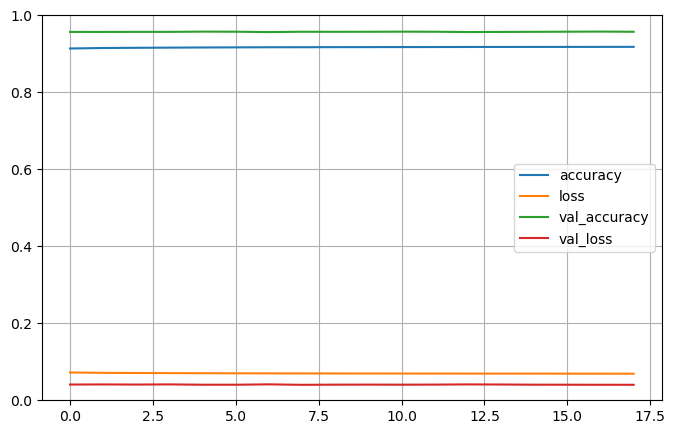

In [53]:
pd.DataFrame(history.history).plot(figsize=(8, 5)) 
plt.grid(True)
plt.gca().set_ylim(0, 1)

**Evaluate on the test set**

In [55]:
y_predicted = model.predict(X_test)

30625/30625 ━━━━━━━━━━━━━━━━━━━━ 205s 7ms/step


In [ ]:
y_predicted = model.predict(X_test)
y_predicted = np.round(
    )
result = get_performace(test_set, y_predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
performance.head(10)

In [ ]:
performance.to_csv(r'C:\caocao\gnw-master\ANN\single_size\test\performance\size50.csv')

In [ ]:
y_predicted = model.predict(X_test)
predicted = get_round(y_predicted, 0.08)
result = get_performace(test_set, predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
performance.head(10)
performance.to_csv(r'C:\caocao\gnw-master\ANN\single_size\test\performance\size50_imbalanced_threshold008.csv')

In [ ]:
#y_predicted = model.predict(X_test)
predicted = get_round(y_predicted, 0.1)
result = get_performace(test_set, predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
#performance.to_csv(r'C:\caocao\gnw-master\ANN\single_size\test\performance\size50_imbalanced_threshold01.csv')
performance.head(10)

In [ ]:
y_predicted = model.predict(X_test)
predicted = get_round(y_predicted, 0.15)
result = get_performace(test_set, predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
performance.to_csv(r'C:\caocao\gnw-master\ANN\single_size\test\performance\size50_imbalanced_threshold015.csv')
performance.head(10)

In [ ]:
y_predicted = model.predict(X_test)
predicted = get_round(y_predicted, 0.2)
result = get_performace(test_set, predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
performance.to_csv(r'C:\caocao\gnw-master\ANN\single_size\test\performance\size50_imbalanced_threshold02.csv')
performance.head(10)

In [ ]:
#y_predicted = model.predict(X_test)
predicted = get_round(y_predicted, 0.25)
result = get_performace(test_set, predicted)
performance = pd.DataFrame.from_dict(result, orient='index')
performance.to_csv(r'C:\caocao\gnw-master\ANN\single_size\test\performance\size50_imbalanced_threshold025.csv')
performance.head(10)

**ROC curve**

In [57]:
def performance_metrics1(y, y_predicted):
    tp=fp=tn=fn=0
    for i in range(len(y)):
        if y[i]==y_predicted[i]:
            if y[i]==1:
                tp+=1
            else:
                tn+=1
        else:
            if y[i]==1:
                fn+=1
            else:
                fp+=1
    precision = tp/(tp+fp) if (tp+fp)!=0 else 0
    recall = tp/(tp+fn) if (tp+fn)!=0 else 0
    structural = (tp+tn)/(tp+fp+fn+tn)
    tpr = recall
    fpr = fp/(fp+tn) if (fp+tn)!=0 else 1
    return precision, recall, structural, tpr, fpr

In [59]:
def get_performace1(test_set, y_predicted):
    test_set['predicted'] = y_predicted
    result={}
    sample = set(test_set['sample'].values)
    for sp in sample:
        network = test_set[test_set['sample']==sp]
        p,r,st, tpr, fpr = performance_metrics1(network['interaction'].values, network['predicted'].values)
        result[f'{sp}'] = {'precision':round(p, 4), 'recall':round(r,4), 'structural': round(st,4), 
                           'tpr':round(tpr, 4), 'fpr':round(fpr, 4)}
    return result

In [71]:
thresholds = [i/100 for i in range(100, 0, -1)]
performances = []
for threshold in thresholds:
    predicted = get_round(y_predicted, threshold)
    result = get_performace1(test_set, predicted)
    performance = pd.DataFrame.from_dict(result, orient='index')
    performances.append(performance)
    performance.to_csv(fr'C:\caocao\ANN\single_size\test\performance\size50_threshold_{threshold}.csv')

In [ ]:
performances[0]

In [72]:
curves_info = {i:[[],[]] for i in range(100)}
for per in performances:
    for i in range(100):
        curves_info[i][0].append(per.iloc[i, 3])
        curves_info[i][1].append(per.iloc[i, 4])

In [73]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    'font.size': 12,              # Default font size for text
    'axes.titlesize': 20,         # Font size for axes titles
    'axes.labelsize': 15,         # Font size for x and y labels
    'xtick.labelsize': 12,        # Font size for x tick labels
    'ytick.labelsize': 12,        # Font size for y tick labels
    'legend.fontsize': 12,        # Font size for legend
    'figure.titlesize': 22        # Font size for figure title
})
plt.tick_params(axis='both',        # Apply changes to both x and y axes
                which='major',      # Apply changes to major ticks
                direction='inout',    # Ticks pointing outwards
                length=10,          # Length of ticks
                width=2           # Width of ticks
                #colors='red',       # Color of ticks
                #grid_color='black', # Color of gridlines
                #grid_alpha=0.5)     # Transparency of gridlines
               )
plt.xlim(0, 0.35)
plt.ylim(0, 0.8)
for k, v in curves_info.items():
    
    plt.plot(v[1], v[0], linewidth=3, marker='o', linestyle='dashed', color='#ff4f00')   
    plt.fill_between(v[1], v[0], color='#99ce3e', alpha=0.4)
    plt.text(0.2, 0.3, 'AUC', fontsize=14, color='#0d929a', ha='center', weight='bold')
    plt.text(0.07, 0.4, 'ROC', fontsize=14, color='#0d929a', ha='center',  weight='bold')
    plt.plot([0,v[1][-1]], [0, v[0][-1]], linewidth=3, linestyle='solid', color='#650000')
    plt.title(f'ROC curve - sample {k}')
    plt.xlabel('FP Rate')
    plt.ylabel('TP Rate')
    plt.savefig(fr'C:\caocao\ANN\single_size\test\performance\ROC\s50_{k}.png')
    plt.clf()

<Figure size 800x600 with 0 Axes>